### State Schema with Data Classes

- When we define a LangGraph StateGraph, we use a state schema
- The state schema represents the structure and types of data our graph will use
- All nodes are expected to communicate with that schema.
- LangGraph offers flexibility in how you define your state schema

In [2]:
from typing_extensions import TypedDict 
from langgraph.graph import StateGraph, START, END
from typing import Literal, Annotated

class TypeDictState(TypedDict):
    name: str
    game: Literal["chess", "football", "cricket"]


In [3]:
def play_game(state: TypeDictState):
    print("---Playing Game Node---")
    return {
        "name": state["name"] + " wants to play"
    }

def cricket(state:TypeDictState):
    print("---Cricket Node called---")
    return {
        "name": state["name"] + " cricket ",
        "game": "cricket"
    }

def football(state: TypeDictState):
    print("---Football Node called---")
    return {
        "name": state["name"] + " football ",
        "game": "football"
    }

def chess(state: TypeDictState):
    print("---Chess Node called---")
    return {
        "name": state["name"] + " chess ",
        "game": "chess"
    }

def return_home(state: TypeDictState):
    print("---Return Home node called---")
    return {
        "name": state["name"] + "he finished playing and gone home"
    }

In [4]:
import random

def decide_play(state: TypeDictState) -> Literal["chess", "football", "cricket"]:
    print("---Decide Play Node called---")
    if random.random() < 0.33:
        return "cricket"
    elif random.random() < 0.66:
        return "football"
    else:
        return "chess"

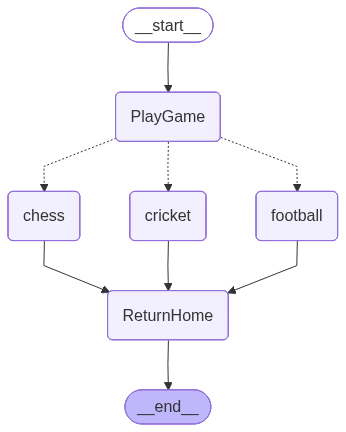

In [5]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

# Initializing the graph
graph = StateGraph(TypeDictState)

# Adding the nodes to the graph
graph.add_node("PlayGame", play_game)
graph.add_node("cricket", cricket)
graph.add_node("football", football)
graph.add_node("chess", chess)
graph.add_node("ReturnHome", return_home)

# Adding edges  for each node
graph.add_edge(START, "PlayGame")
graph.add_conditional_edges("PlayGame", decide_play)
graph.add_edge("cricket", "ReturnHome")
graph.add_edge("football", "ReturnHome")
graph.add_edge("chess", "ReturnHome")

graph.add_edge("ReturnHome", END)

# Compiling the graph
graph_builder = graph.compile()

# Visualiziing the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [6]:
graph_builder.invoke({
    "name": "Anurag"
})

---Playing Game Node---
---Decide Play Node called---
---Football Node called---
---Return Home node called---


{'name': 'Anurag wants to play football he finished playing and gone home',
 'game': 'football'}

### DataClasses

- Python's DataClasses provide another way to define structured data
- DataClasses offer a concise syntax for creating classes that are primarily used to store data

In [7]:
from dataclasses import dataclass

@dataclass
class DataClassState:
    name: str
    game: Literal["chess", "cricket", "badminton"]

In [8]:
def play_game(state: DataClassState):
    print("---Playing Game Node---")
    return {
        "name": state["name"] + " wants to play"
    }

def cricket(state: DataClassState):
    print("---Cricket Node called---")
    return {
        "name": state["name"] + " cricket ",
        "game": "cricket"
    }

def badminton(state: DataClassState):
    print("---Badminton Node called---")
    return {
        "name": state["name"] + " badminton ",
        "game": "badminton"
    }

def chess(state: DataClassState):
    print("---Chess Node called---")
    return {
        "name": state["name"] + " chess ",
        "game": "chess"
    }

def return_home(state: DataClassState):
    print("---Return Home node called---")
    return {
        "name": state["name"] + "he finished playing and gone home"
    }

In [9]:
import random

def decide_play(state: DataClassState) -> Literal["chess", "badminton", "cricket"]:
    print("---Decide Play Node called---")
    if random.random() < 0.33:
        return "cricket"
    elif random.random() < 0.66:
        return "badminton"
    else:
        return "chess"

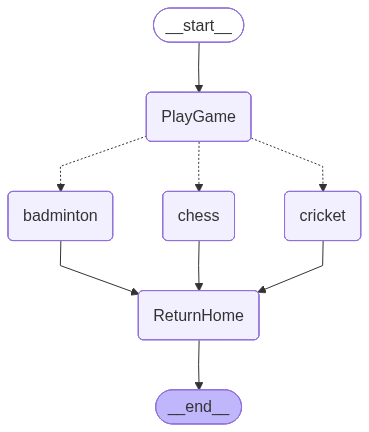

In [11]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

# Initializing the graph
graph = StateGraph(DataClassState)

# Adding the nodes to the graph
graph.add_node("PlayGame", play_game)
graph.add_node("cricket", cricket)
graph.add_node("badminton", badminton)
graph.add_node("chess", chess)
graph.add_node("ReturnHome", return_home)

# Adding edges  for each node
graph.add_edge(START, "PlayGame")
graph.add_conditional_edges("PlayGame", decide_play)
graph.add_edge("cricket", "ReturnHome")
graph.add_edge("badminton", "ReturnHome")
graph.add_edge("chess", "ReturnHome")

graph.add_edge("ReturnHome", END)

# Compiling the graph
graph_builder = graph.compile()

# Visualiziing the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [45]:
# Invoking the graph

graph_builder.invoke(DataClassState(
    name="Rohan",
    game="None"
))

---Playing Game Node---


TypeError: 'DataClassState' object is not subscriptable

### PyDantic - Data Validation

In [52]:
from pydantic import BaseModel

class PyState(BaseModel):
    name: str
    age: int

In [53]:
def eg_node(state: PyState):
    return {
        "name": "Hello"
    }

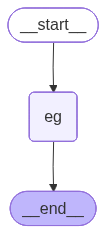

In [54]:
graph = StateGraph(PyState)
graph.add_node("eg", eg_node)

graph.add_edge(START, "eg")
graph.add_edge("eg", END)

builder = graph.compile()

display(Image(builder.get_graph().draw_mermaid_png()))

In [55]:
builder.invoke({
    "name": "Rahul Sharma"
})

ValidationError: 1 validation error for PyState
age
  Field required [type=missing, input_value={'name': 'Rahul Sharma'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing